# Alucar - Analisando as Vendas

In [1]:
import pandas as pd

In [2]:
uri_alucar = r'C:\Users\Usuario\Documents\Estudos\ALURA\05_Data_Science\raw\alucar.csv'
alucar = pd.read_csv(uri_alucar)
alucar.head()

,mes,vendas
0,2017-01-31,10
1,2017-02-28,20
2,2017-03-31,33
3,2017-04-30,47
4,2017-05-31,63


In [3]:
print(f'Quantidade de Linhas e Colunas: {alucar.shape}')
print(f'Qtd de dados nulos: {alucar.isna().sum().sum()}')

Quantidade de Linhas e Colunas: (24, 2)
Qtd de dados nulos: 0


In [4]:
alucar.dtypes

mes       object
vendas     int64
dtype: object

In [5]:
alucar['mes'] = pd.to_datetime(alucar['mes'])
alucar.dtypes

mes       datetime64[ns]
vendas             int64
dtype: object

In [6]:
import seaborn as sns
%matplotlib inline
from matplotlib import pyplot as  plt

In [7]:
print(sns.__version__)

0.13.2


<Axes: xlabel='mes', ylabel='vendas'>

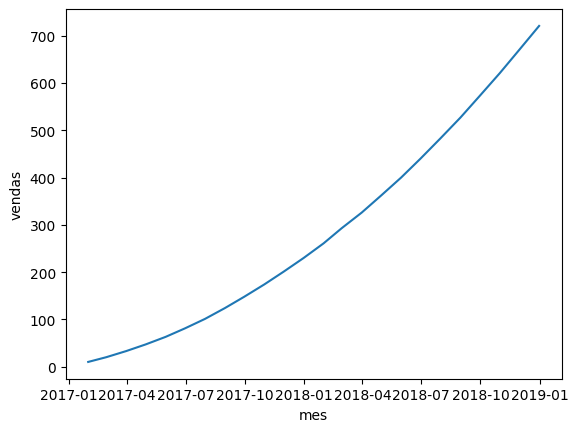

In [8]:
sns.lineplot(x='mes', y='vendas', data=alucar)

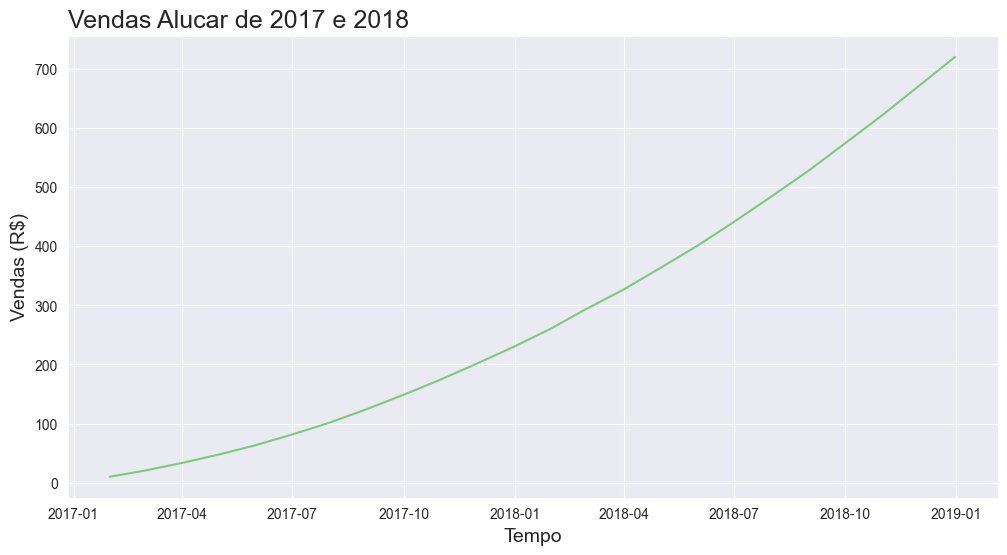

In [9]:
sns.set_palette('Accent')
sns.set_style('darkgrid')
ax = sns.lineplot(x='mes', y='vendas', data=alucar);
ax.figure.set_size_inches(12, 6)
ax.set_title('Vendas Alucar de 2017 e 2018', loc='left', fontsize=18)
ax.set_xlabel('Tempo', fontsize=14)
ax.set_ylabel('Vendas (R$)', fontsize=14)
ax = ax

In [10]:
alucar['aumento'] = alucar.vendas.diff()
alucar.head()

,mes,vendas,aumento
0,2017-01-31,10,NaN
1,2017-02-28,20,10.0
2,2017-03-31,33,13.0
3,2017-04-30,47,14.0
4,2017-05-31,63,16.0


In [11]:
def plotar(titulo, labelx, labely, x, y, dataset):
    sns.set_palette('Accent')
    sns.set_style('darkgrid')
    ax = sns.lineplot(x=x, y=y, data=dataset);
    ax.figure.set_size_inches(12, 6)
    ax.set_title(titulo, loc='left', fontsize=18)
    ax.set_xlabel(labelx, fontsize=14)
    ax.set_ylabel(labely, fontsize=14)
    ax = ax

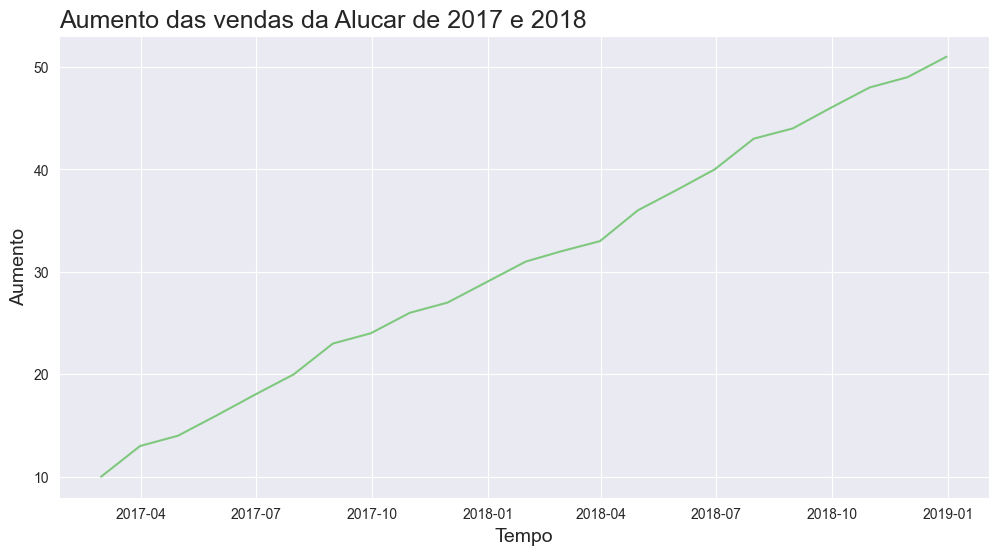

In [12]:
plotar(
    titulo='Aumento das vendas da Alucar de 2017 e 2018',
    labelx='Tempo', labely='Aumento', 
    x='mes', y='aumento', dataset=alucar
)

In [13]:
alucar['aceleracao'] = alucar.aumento.diff()
alucar.head()

,mes,vendas,aumento,aceleracao
0,2017-01-31,10,NaN,NaN
1,2017-02-28,20,10.0,NaN
2,2017-03-31,33,13.0,3.0
3,2017-04-30,47,14.0,1.0
4,2017-05-31,63,16.0,2.0


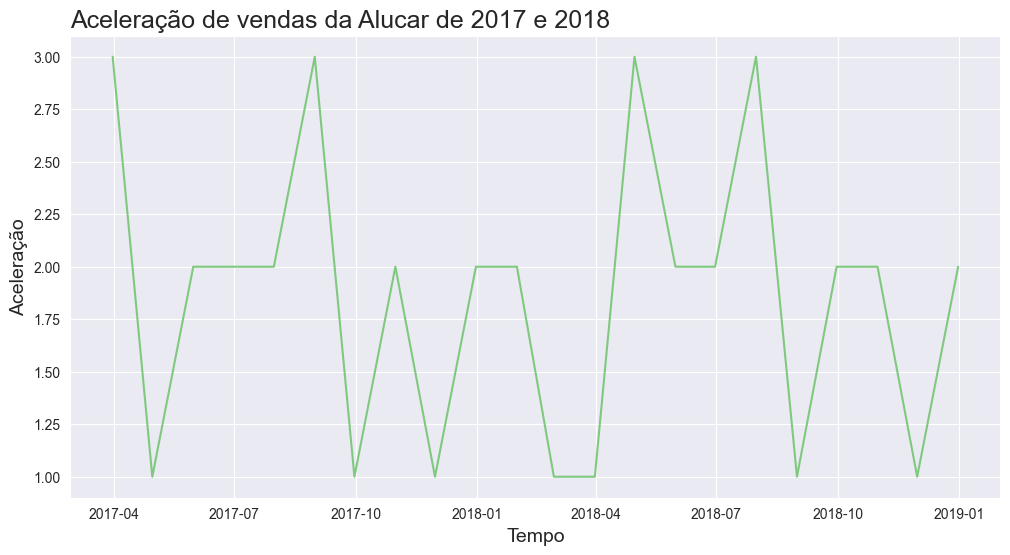

In [14]:
plotar('Aceleração de vendas da Alucar de 2017 e 2018',
       'Tempo', 'Aceleração', 'mes', 'aceleracao', 
       dataset=alucar)

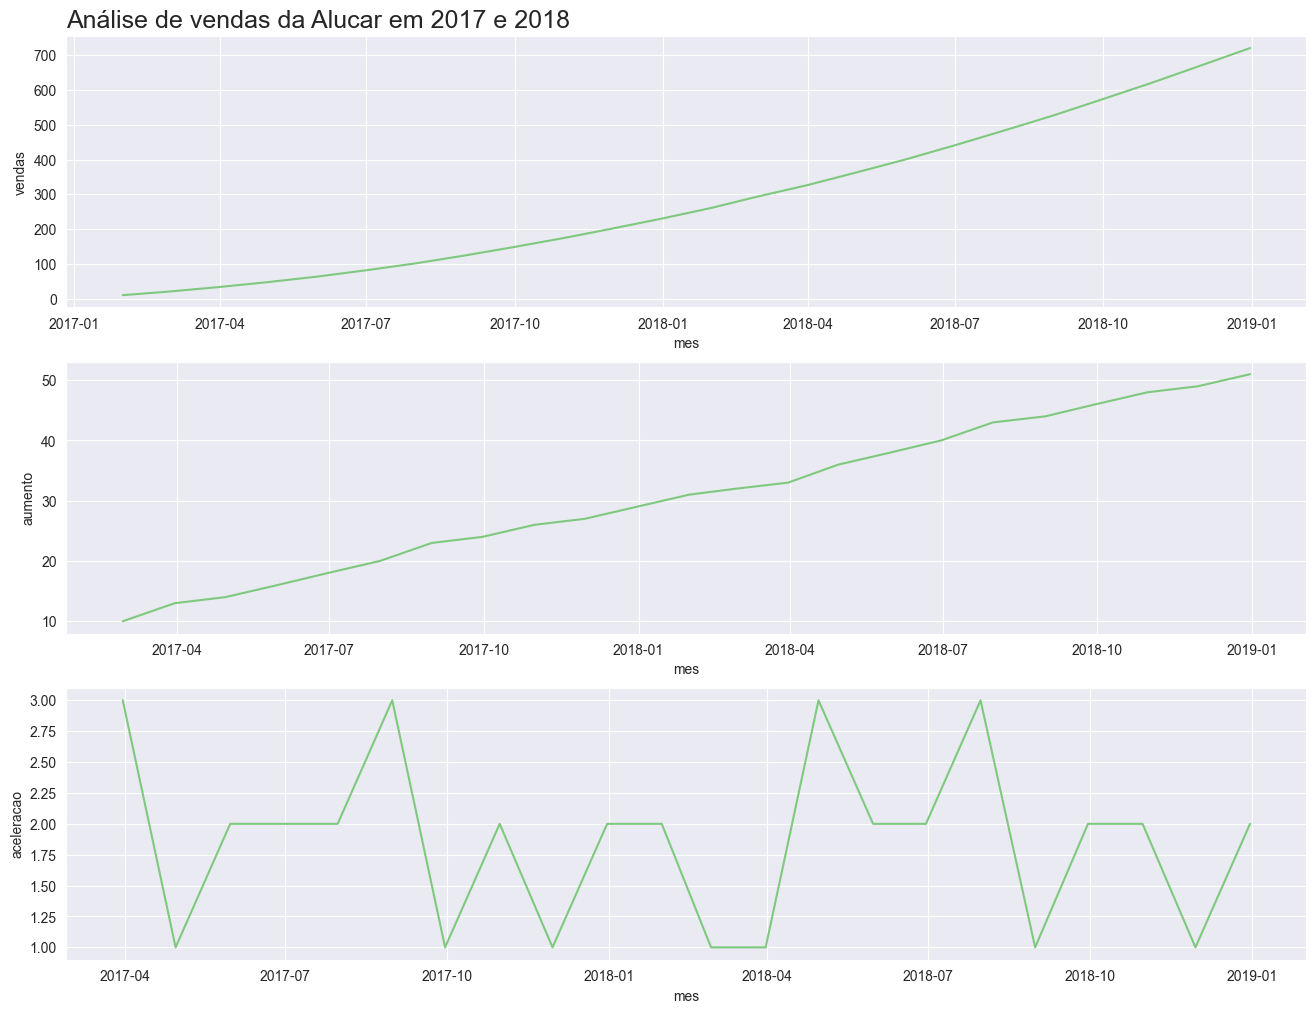

In [15]:
plt.figure(figsize=(16, 12))
ax = plt.subplot(3, 1, 1)
ax.set_title('Análise de vendas da Alucar em 2017 e 2018', fontsize=18, loc='left');
sns.lineplot(x='mes', y='vendas', data=alucar)
plt.subplot(3, 1, 2)
sns.lineplot(x='mes', y='aumento', data=alucar)
plt.subplot(3, 1, 3)
sns.lineplot(x='mes', y='aceleracao', data=alucar);

In [16]:
def plot_comparacao(x, y1, y2, y3, dataset, titulo): 
    plt.figure(figsize=(16, 12))
    ax = plt.subplot(3, 1, 1)
    ax.set_title(titulo, fontsize=18, loc='left');
    sns.lineplot(x=x, y=y1, data=dataset)
    plt.subplot(3, 1, 2)
    sns.lineplot(x=x, y=y2, data=dataset)
    plt.subplot(3, 1, 3)
    sns.lineplot(x=x, y=y3, data=dataset);

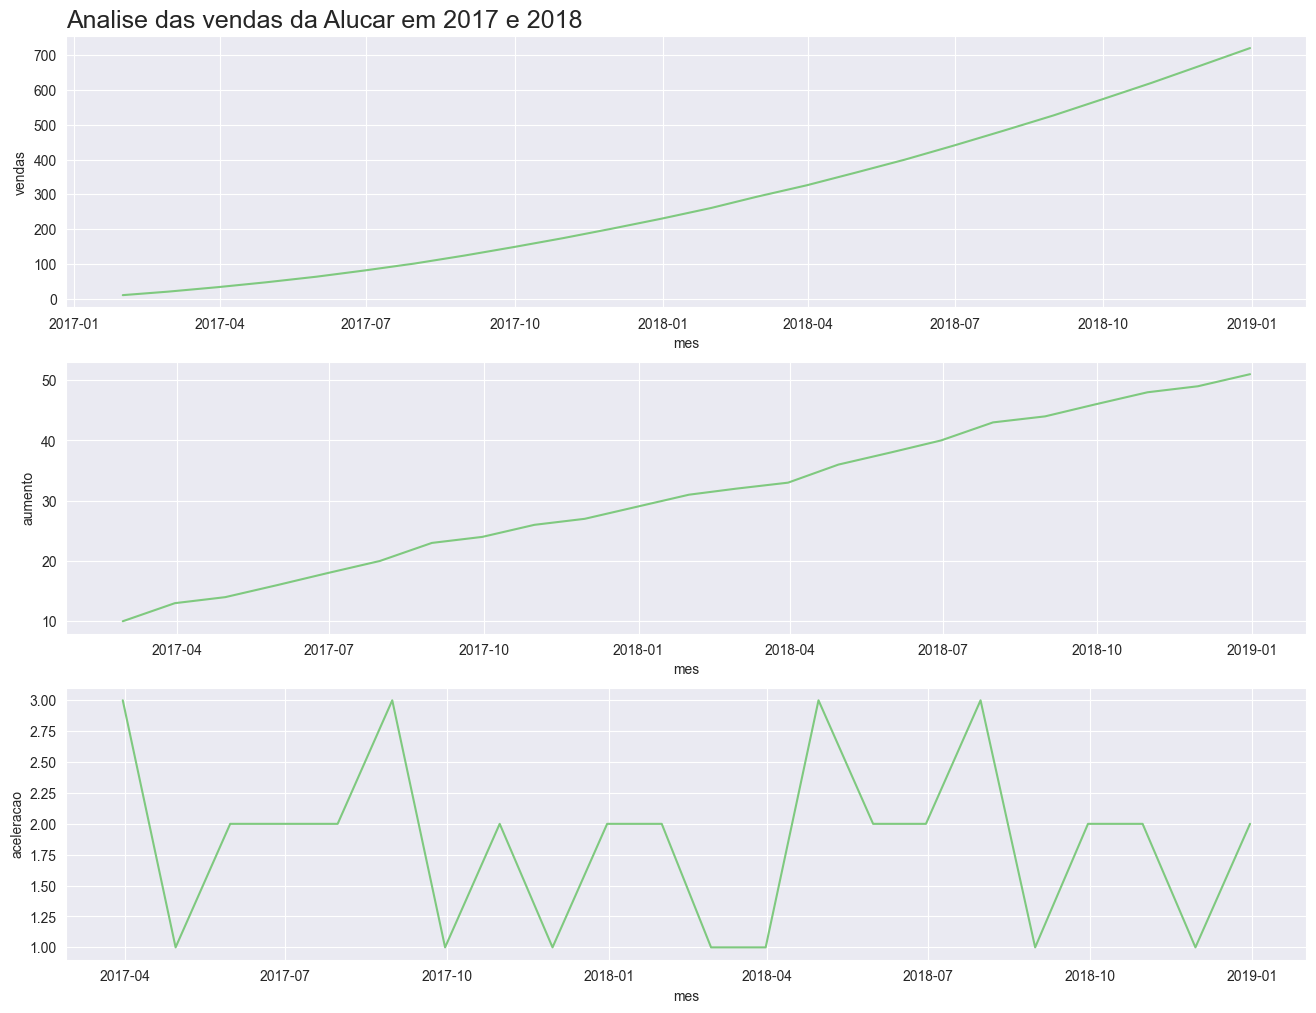

In [17]:
plot_comparacao('mes', 'vendas', 'aumento', 'aceleracao', alucar, 'Analise das vendas da Alucar em 2017 e 2018')

## Autocorrelação

In [18]:
from pandas.plotting import autocorrelation_plot

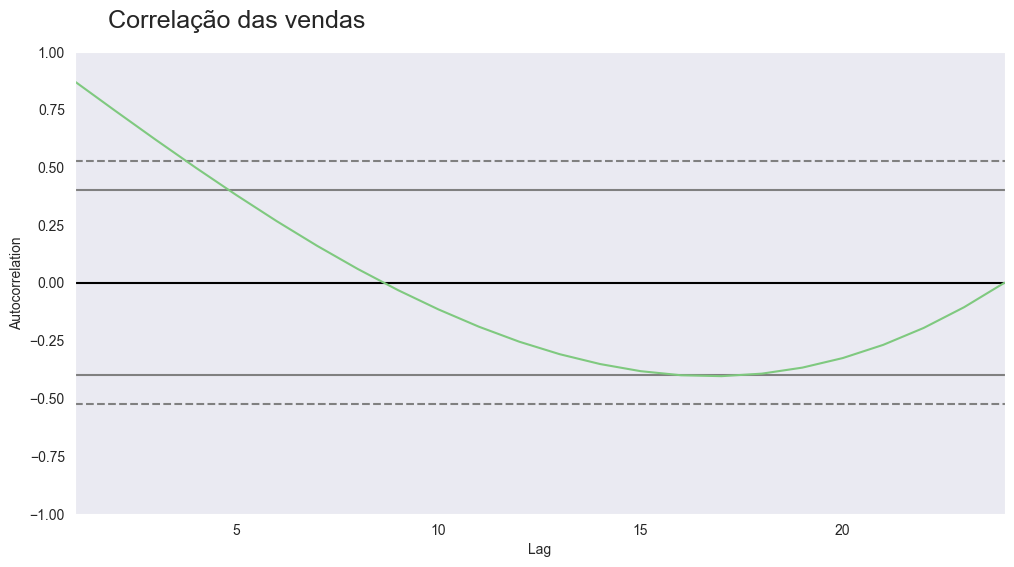

In [19]:
ax = plt.figure(figsize=(12,6))
ax.suptitle('Correlação das vendas', fontsize=18, x=0.26, y=0.95)
autocorrelation_plot(alucar.vendas);

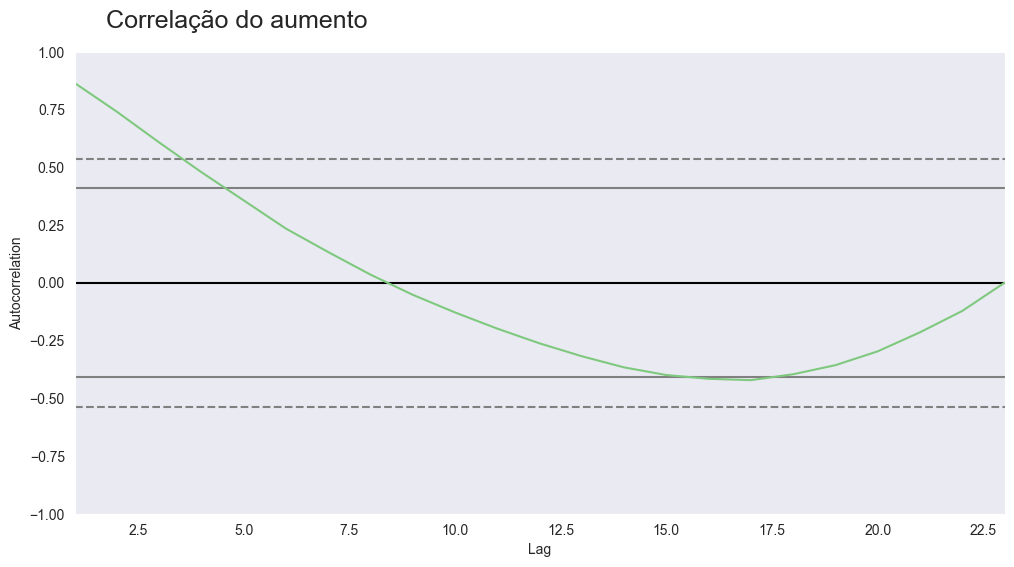

In [20]:
ax = plt.figure(figsize=(12,6))
ax.suptitle('Correlação do aumento', fontsize=18, x=0.26, y=0.95)
autocorrelation_plot(alucar.aumento[1:]);

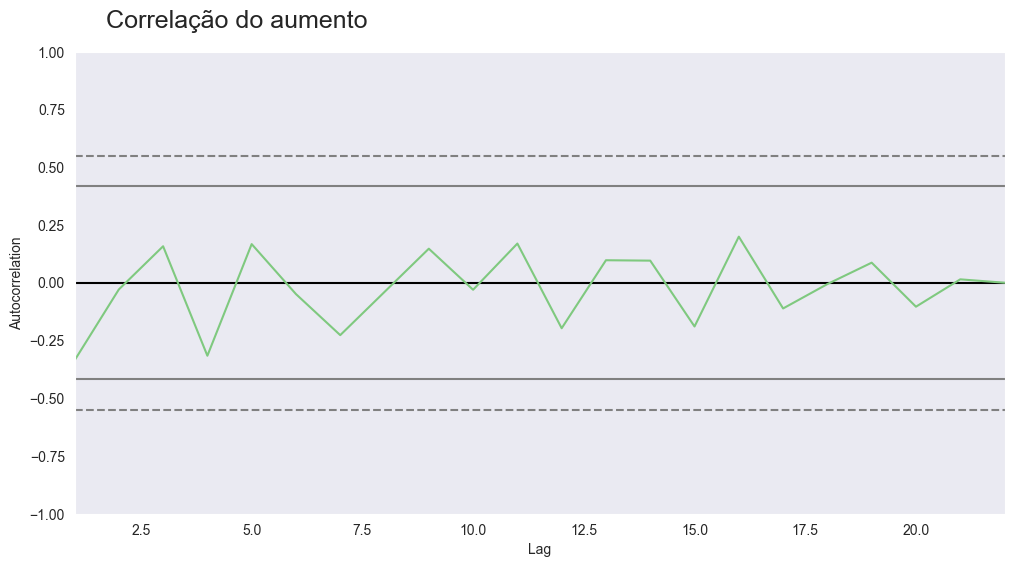

In [21]:
ax = plt.figure(figsize=(12,6))
ax.suptitle('Correlação do aumento', fontsize=18, x=0.26, y=0.95)
autocorrelation_plot(alucar.aceleracao[2:]);

# Alucar - Analisando assinantes da newsletter

In [22]:
uri_assinantes = r'C:\Users\Usuario\Documents\Estudos\ALURA\05_Data_Science\raw\newsletter_alucar.csv'
assinantes = pd.read_csv(uri_assinantes)
assinantes.head()

,mes,assinantes
0,2017-01-31,0
1,2017-02-28,10
2,2017-03-31,21
3,2017-04-30,34
4,2017-05-31,49


In [23]:
print(f'Qtd de linhas e colunas: {assinantes.shape}')
print(f'Qtd de dados nulos: {assinantes.isna().sum().sum()}')

Qtd de linhas e colunas: (24, 2)
Qtd de dados nulos: 0


In [24]:
assinantes['mes'] = pd.to_datetime(assinantes['mes'])
assinantes.dtypes

mes           datetime64[ns]
assinantes             int64
dtype: object

In [25]:
assinantes['aumento'] = assinantes['assinantes'].diff()
assinantes['aceleracao'] = assinantes['aumento'].diff()
assinantes.head()

,mes,assinantes,aumento,aceleracao
0,2017-01-31,0,NaN,NaN
1,2017-02-28,10,10.0,NaN
2,2017-03-31,21,11.0,1.0
3,2017-04-30,34,13.0,2.0
4,2017-05-31,49,15.0,2.0


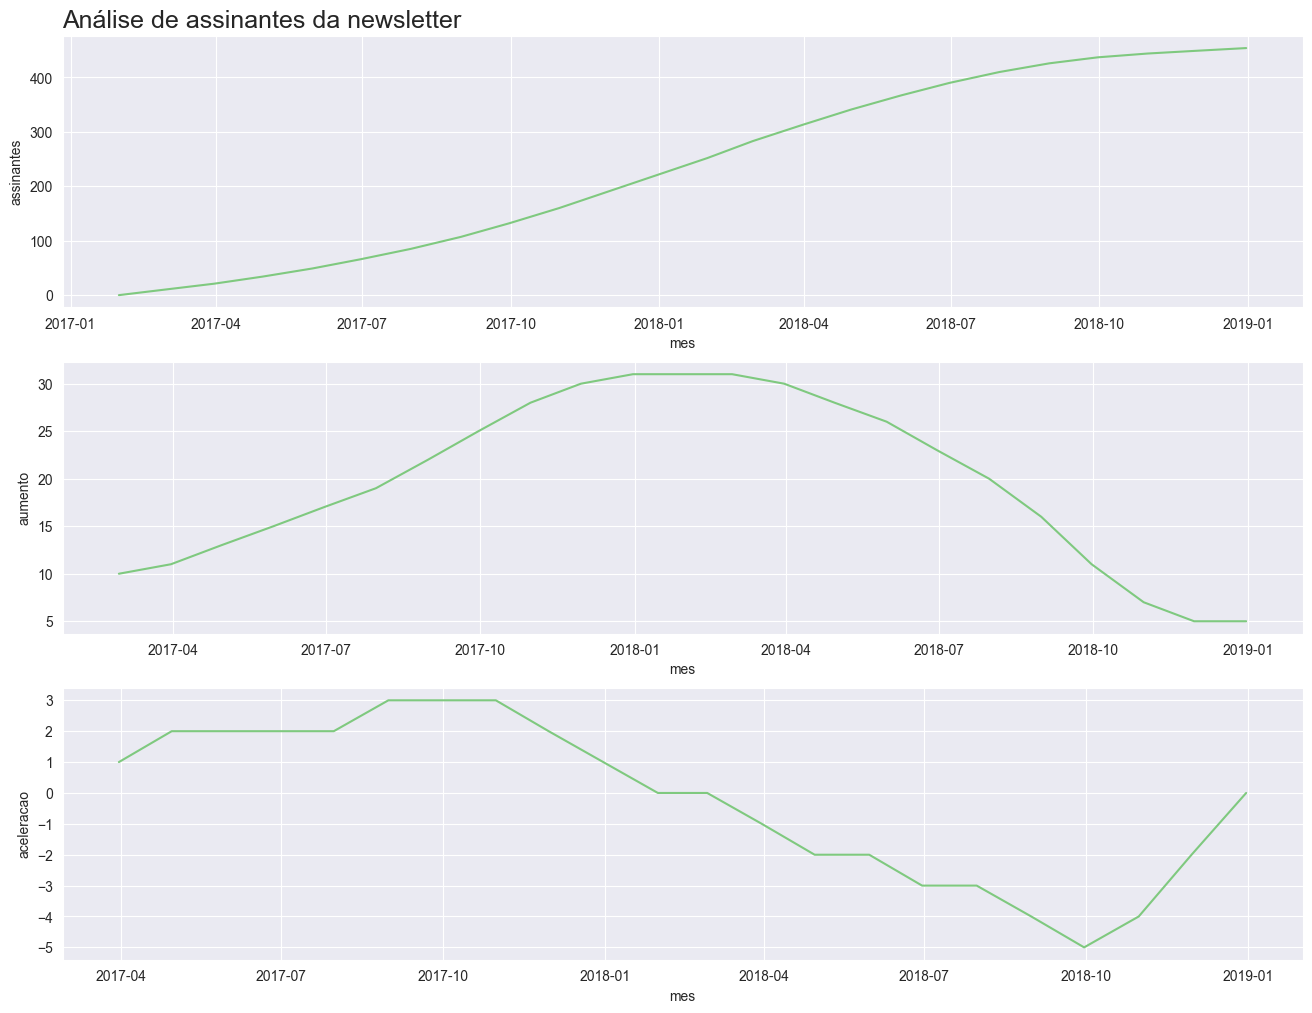

In [26]:
plot_comparacao('mes', 'assinantes', 'aumento', 'aceleracao', assinantes, 'Análise de assinantes da newsletter')

# Chocolura - Analisando as vendas

In [27]:
uri_chocolura = r'C:\Users\Usuario\Documents\Estudos\ALURA\05_Data_Science\raw\chocolura.csv'
chocolura = pd.read_csv(uri_chocolura)
chocolura.head()

,mes,vendas
0,2017-01,210
1,2017-02,185
2,2017-03,209
3,2017-04,280
4,2017-05,211


In [28]:
chocolura['mes'] = pd.to_datetime(chocolura['mes'])
chocolura.dtypes

mes       datetime64[ns]
vendas             int64
dtype: object

In [29]:
print(f'Qtd de linhas e colunas: {chocolura.shape}')
print(f'Qtd de dados nulos: {chocolura.isna().sum().sum()}')

Qtd de linhas e colunas: (24, 2)
Qtd de dados nulos: 0


In [30]:
chocolura['aumento'] = chocolura['vendas'].diff()
chocolura['aceleracao'] = chocolura['aumento'].diff()
chocolura.head()

,mes,vendas,aumento,aceleracao
0,2017-01-01,210,NaN,NaN
1,2017-02-01,185,-25.0,NaN
2,2017-03-01,209,24.0,49.0
3,2017-04-01,280,71.0,47.0
4,2017-05-01,211,-69.0,-140.0


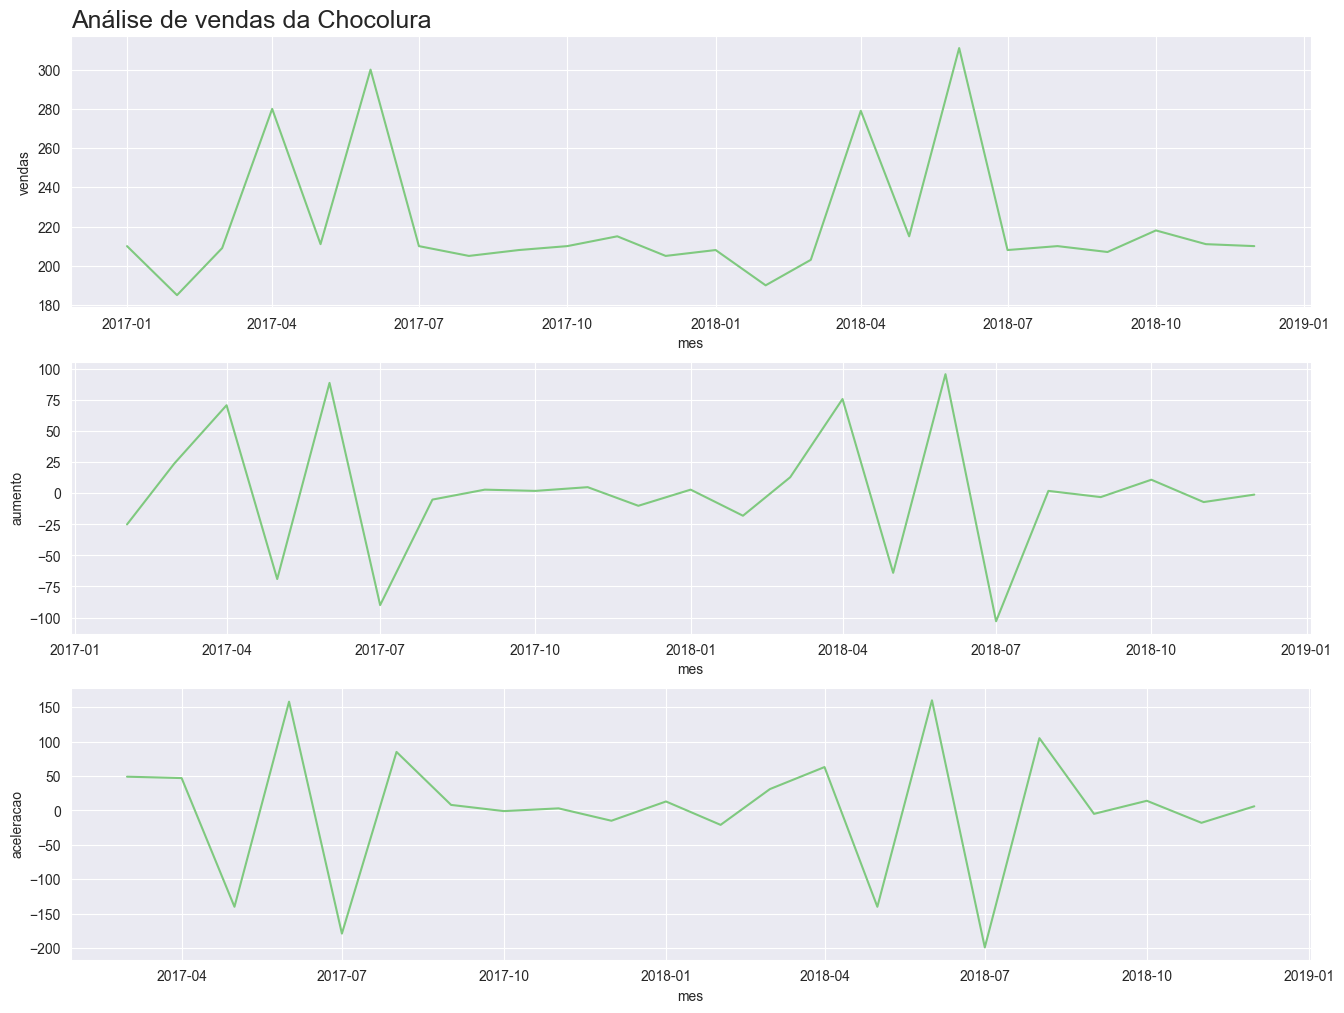

In [31]:
plot_comparacao('mes', 'vendas', 'aumento', 'aceleracao', chocolura, 'Análise de vendas da Chocolura')

# Chocolura - Vendas Diárias (Outubro e Novembro)

In [32]:
uri_vendas_por_dia = r'C:\Users\Usuario\Documents\Estudos\ALURA\05_Data_Science\raw\vendas_por_dia.csv'
vendas_por_dia = pd.read_csv(uri_vendas_por_dia)
vendas_por_dia.head()

,dia,vendas
0,2018-10-01,50
1,2018-10-02,48
2,2018-10-03,56
3,2018-10-04,50
4,2018-10-05,51


In [33]:
vendas_por_dia['dia'] = pd.to_datetime(vendas_por_dia['dia'])
print(f'Qtd de linhas e colunas: {vendas_por_dia.shape}')
print(f'Qtd de dados nulos: {vendas_por_dia.isna().sum().sum()}')

Qtd de linhas e colunas: (61, 2)
Qtd de dados nulos: 0


In [34]:
vendas_por_dia['aumento'] = vendas_por_dia['vendas'].diff()
vendas_por_dia['aceleracao'] = vendas_por_dia['aumento'].diff()
vendas_por_dia.head()

,dia,vendas,aumento,aceleracao
0,2018-10-01,50,NaN,NaN
1,2018-10-02,48,-2.0,NaN
2,2018-10-03,56,8.0,10.0
3,2018-10-04,50,-6.0,-14.0
4,2018-10-05,51,1.0,7.0


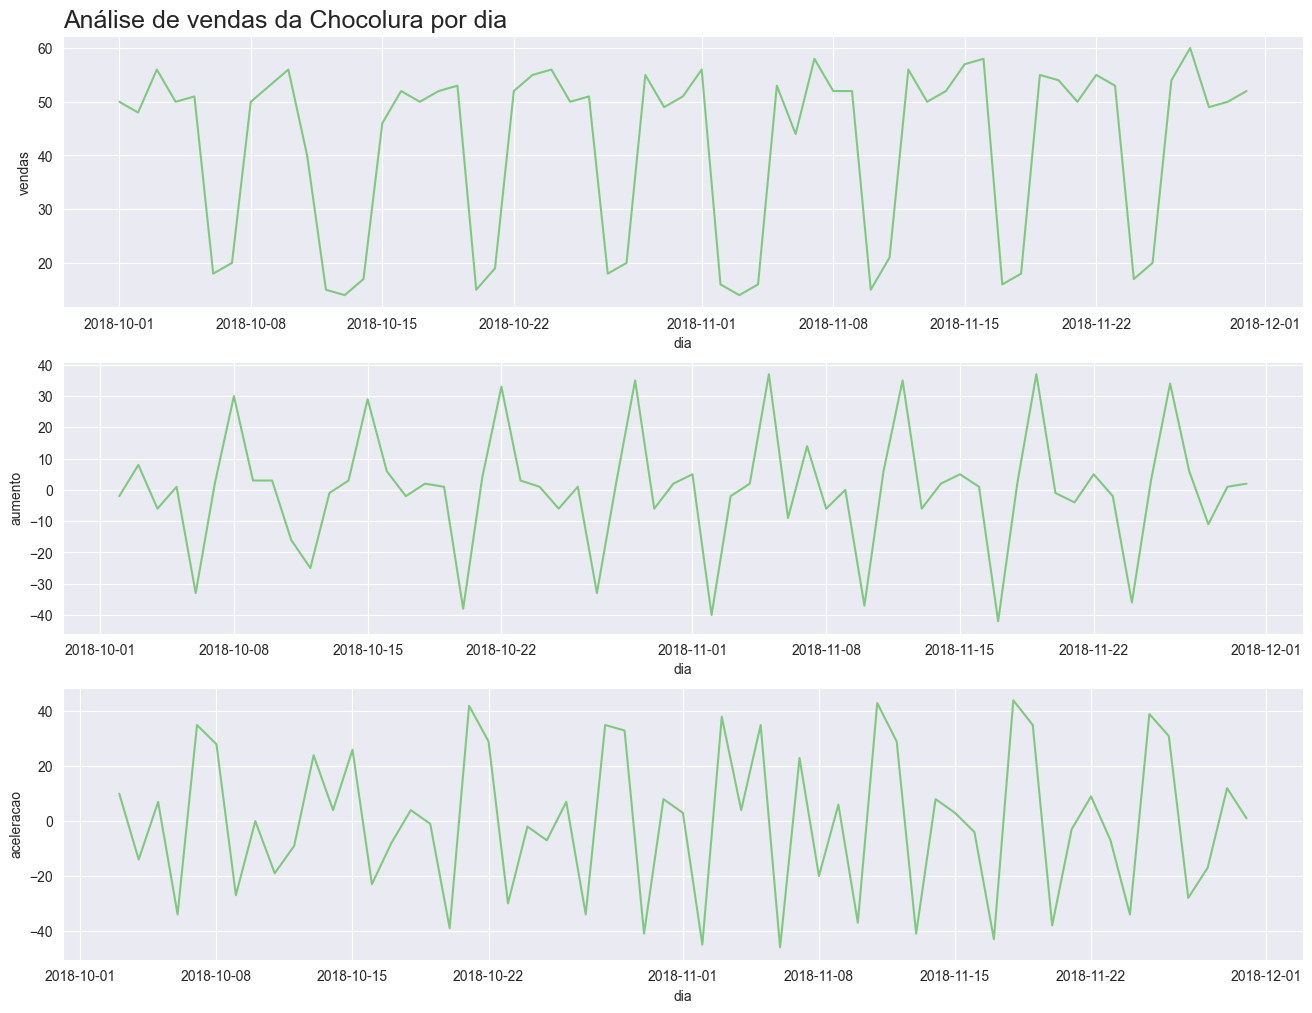

In [35]:
plot_comparacao('dia', 'vendas', 'aumento', 'aceleracao', vendas_por_dia, 'Análise de vendas da Chocolura por dia')

## Analisando a sazonalidade

In [36]:
vendas_por_dia['dia_da_semana'] = vendas_por_dia['dia'].dt.day_name()

In [37]:
vendas_por_dia.head()

,dia,vendas,aumento,aceleracao,dia_da_semana
0,2018-10-01,50,NaN,NaN,Monday
1,2018-10-02,48,-2.0,NaN,Tuesday
2,2018-10-03,56,8.0,10.0,Wednesday
3,2018-10-04,50,-6.0,-14.0,Thursday
4,2018-10-05,51,1.0,7.0,Friday


In [38]:
vendas_por_dia['dia_da_semana'].unique()

array(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday',
       'Sunday'], dtype=object)

In [39]:
dias_traduzidos = {'Monday': 'Segunda', 'Tuesday': 'Terca', 'Wednesday': 'Quarta', 
                   'Thursday': 'Quinta', 'Friday': 'Sexta', 'Saturday': 'Sabado', 
                   'Sunday': 'Domingo'}

vendas_por_dia['dia_da_semana'] = vendas_por_dia['dia_da_semana'].map(dias_traduzidos)
vendas_por_dia.head()

,dia,vendas,aumento,aceleracao,dia_da_semana
0,2018-10-01,50,NaN,NaN,Segunda
1,2018-10-02,48,-2.0,NaN,Terca
2,2018-10-03,56,8.0,10.0,Quarta
3,2018-10-04,50,-6.0,-14.0,Quinta
4,2018-10-05,51,1.0,7.0,Sexta


In [40]:
vendas_por_dia.head(14)

,dia,vendas,aumento,aceleracao,dia_da_semana
0,2018-10-01,50,NaN,NaN,Segunda
1,2018-10-02,48,-2.0,NaN,Terca
2,2018-10-03,56,8.0,10.0,Quarta
3,2018-10-04,50,-6.0,-14.0,Quinta
4,2018-10-05,51,1.0,7.0,Sexta
5,2018-10-06,18,-33.0,-34.0,Sabado
6,2018-10-07,20,2.0,35.0,Domingo
7,2018-10-08,50,30.0,28.0,Segunda
8,2018-10-09,53,3.0,-27.0,Terca
9,2018-10-10,56,3.0,0.0,Quarta


## Agrupando os dias

In [41]:
vendas_agrupadas = vendas_por_dia.groupby('dia_da_semana')[['vendas', 'aumento', 'aceleracao']].mean().round()

In [42]:
vendas_agrupadas.head(8)

,vendas,aumento,aceleracao
dia_da_semana,,,
Domingo,19.0,3.0,31.0
Quarta,53.0,1.0,2.0
Quinta,51.0,-2.0,-3.0
Sabado,16.0,-28.0,-20.0
Segunda,52.0,34.0,31.0
Sexta,45.0,-7.0,-5.0
Terca,52.0,-1.0,-34.0


## Correlação das vendas diárias

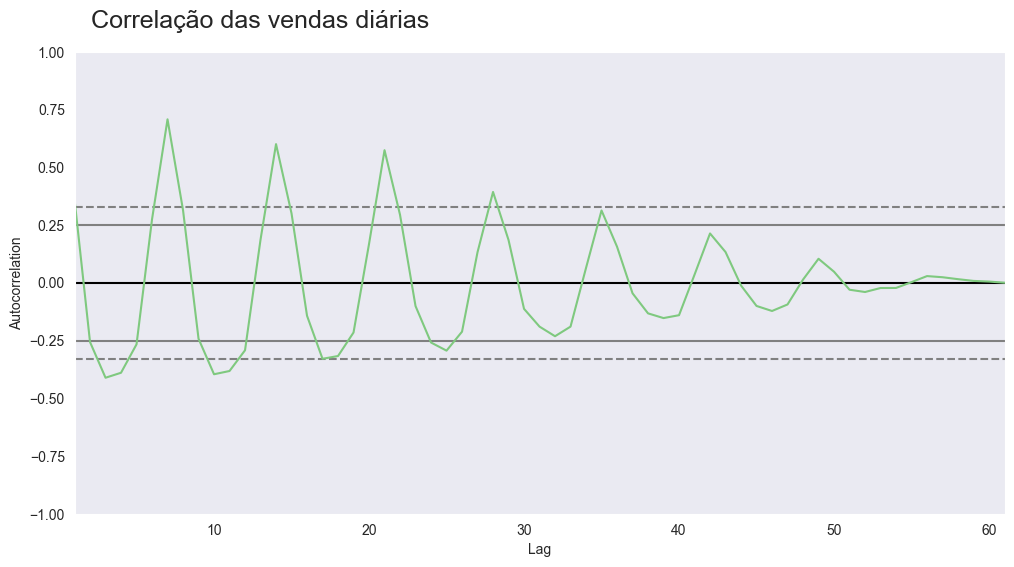

In [43]:
ax = plt.figure(figsize=(12, 6))
ax.suptitle('Correlação das vendas diárias', fontsize=18, x=0.28, y=0.95)
autocorrelation_plot(vendas_por_dia['vendas']);

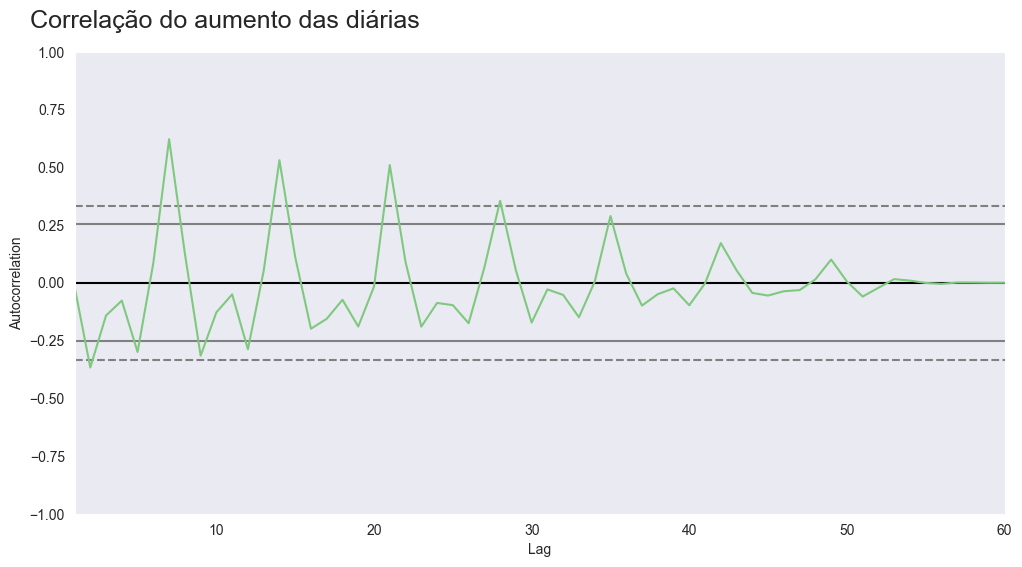

In [44]:
ax = plt.figure(figsize=(12, 6))
ax.suptitle('Correlação do aumento das diárias', fontsize=18, x=0.25, y=0.95)
autocorrelation_plot(vendas_por_dia['aumento'][1:]);

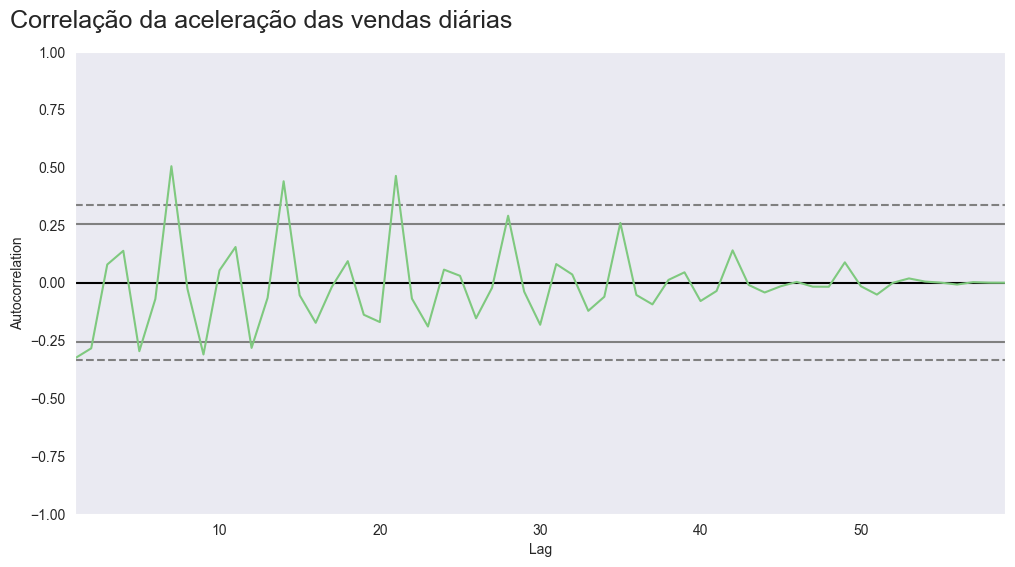

In [45]:
ax = plt.figure(figsize=(12, 6))
ax.suptitle('Correlação da aceleração das vendas diárias', fontsize=18, x=0.28, y=0.95)
autocorrelation_plot(vendas_por_dia['aceleracao'][2:]);

# Cafelura

In [46]:
uri_cafelura = r'C:\Users\Usuario\Documents\Estudos\ALURA\05_Data_Science\raw\cafelura.csv'
cafelura = pd.read_csv(uri_cafelura)
cafelura.head()

,mes,vendas
0,2017-01-31,880
1,2017-02-28,1600
2,2017-03-31,3240
3,2017-04-30,3840
4,2017-05-31,5670


In [47]:
cafelura['mes'] = pd.to_datetime(cafelura['mes'])
print(cafelura.dtypes)
print(cafelura.shape)
print(cafelura.isna().sum().sum())


mes       datetime64[ns]
vendas             int64
dtype: object
(24, 2)
0


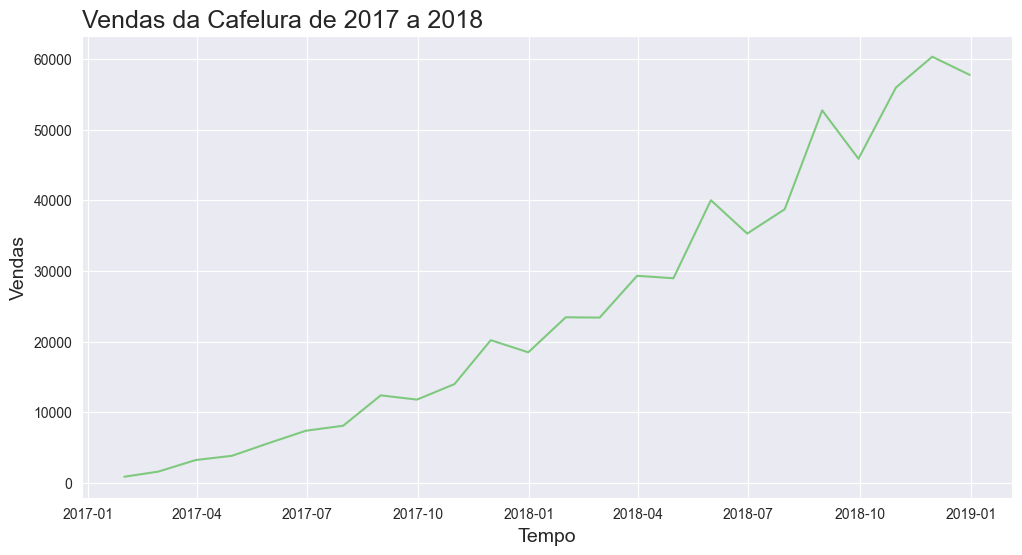

In [48]:
plotar('Vendas da Cafelura de 2017 a 2018', 'Tempo', 'Vendas', 'mes', 'vendas', cafelura)

In [49]:
uri_quantidade_de_dias_de_fds = r'C:\Users\Usuario\Documents\Estudos\ALURA\05_Data_Science\raw\dias_final_de_semana.csv'
quantidade_de_dias_de_fds = pd.read_csv(uri_quantidade_de_dias_de_fds)
quantidade_de_dias_de_fds.head()

,quantidade_de_dias
0,8
1,8
2,10
3,8
4,9


In [50]:
quantidade_de_dias_de_fds['quantidade_de_dias'].values

array([ 8,  8, 10,  8,  9,  9,  8, 10,  8,  8, 10,  8,  9,  8,  9,  8, 10,
        8,  8, 10,  8,  9,  9,  8])

In [51]:
cafelura['vendas_normalizadas'] = cafelura['vendas'] / quantidade_de_dias_de_fds['quantidade_de_dias'].values
cafelura.head()

,mes,vendas,vendas_normalizadas
0,2017-01-31,880,110.0
1,2017-02-28,1600,200.0
2,2017-03-31,3240,324.0
3,2017-04-30,3840,480.0
4,2017-05-31,5670,630.0


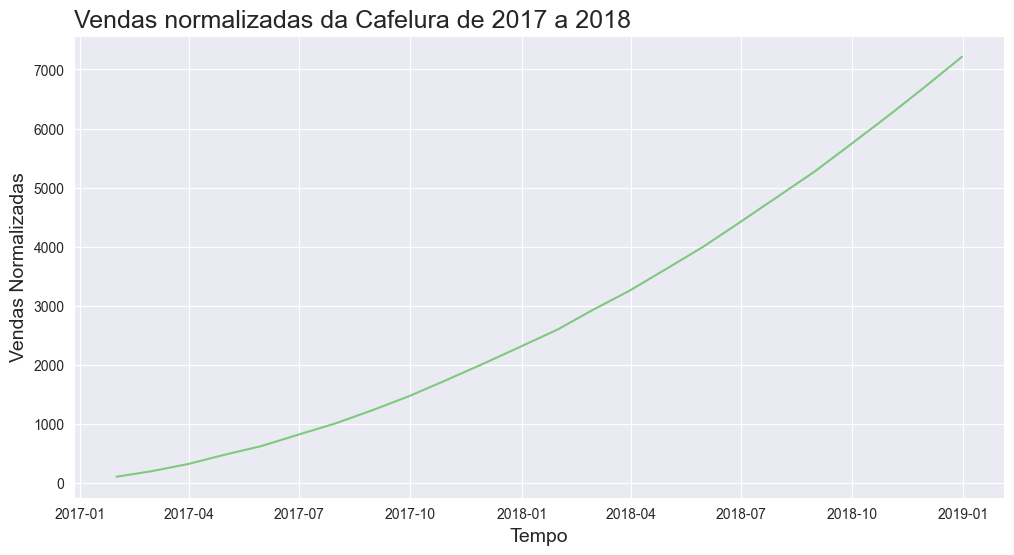

In [52]:
plotar('Vendas normalizadas da Cafelura de 2017 a 2018', 'Tempo', 'Vendas Normalizadas', 'mes', 'vendas_normalizadas', cafelura)

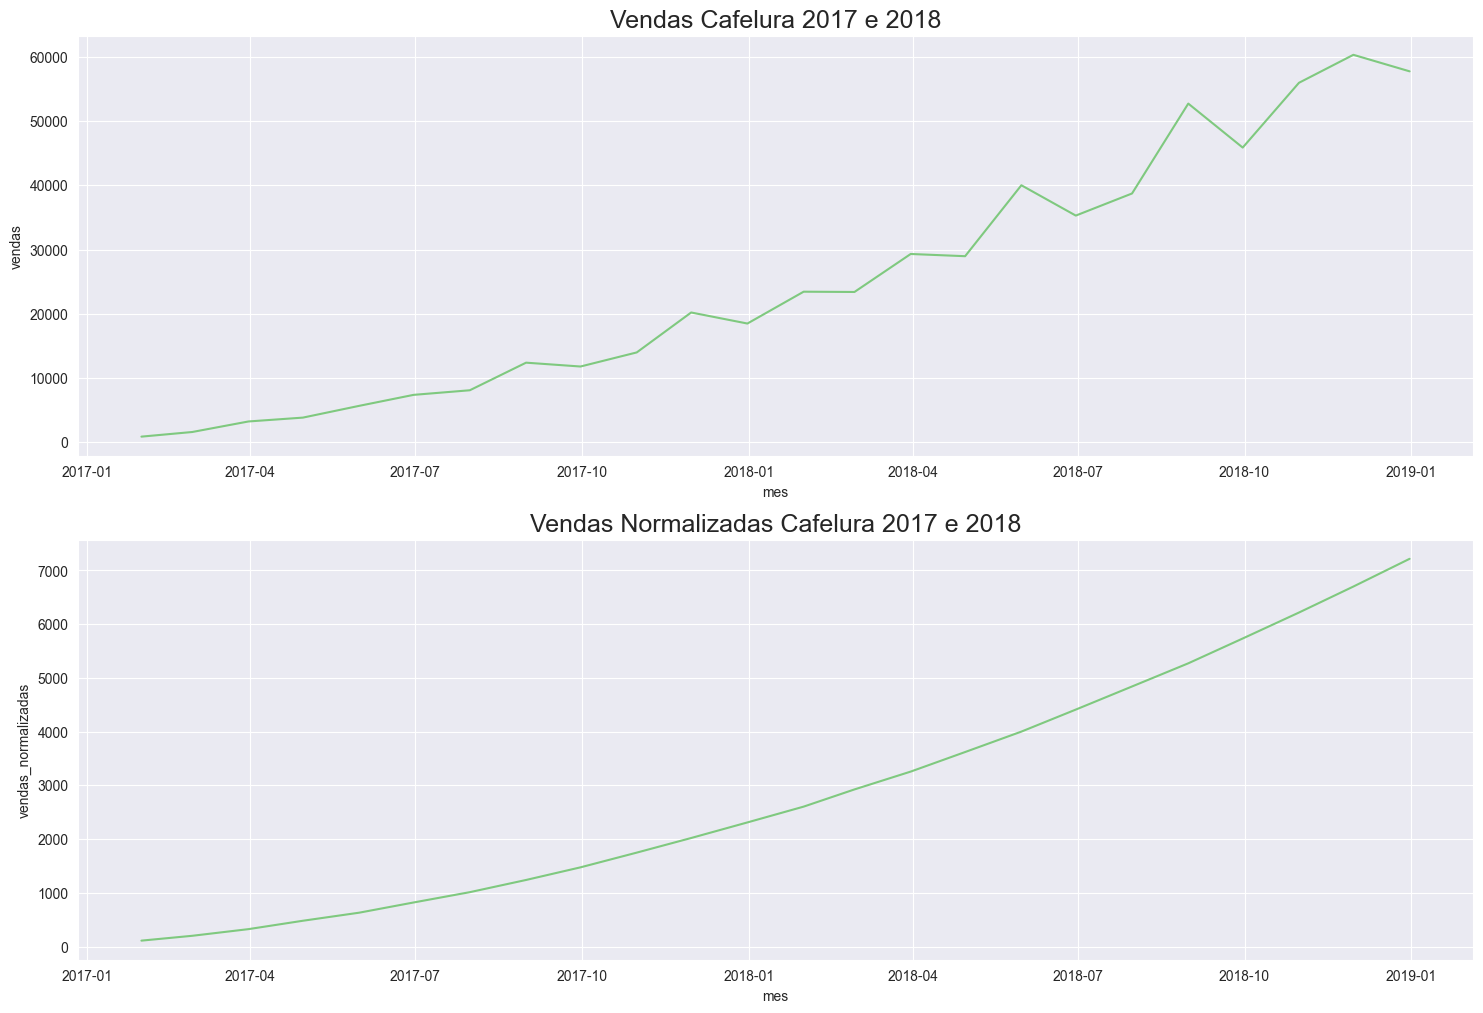

In [53]:
plt.figure(figsize=(18, 12))
ax = plt.subplot(2, 1, 1)
ax.set_title('Vendas Cafelura 2017 e 2018', fontsize=18)
sns.lineplot(x='mes', y='vendas', data=cafelura)
ax = plt.subplot(2, 1, 2)
ax.set_title('Vendas Normalizadas Cafelura 2017 e 2018', fontsize=18)
sns.lineplot(x='mes', y='vendas_normalizadas', data=cafelura);

# Statsmodels

In [ ]:
#!pip install statsmodels --quiet

In [56]:
from statsmodels.tsa.seasonal import seasonal_decompose

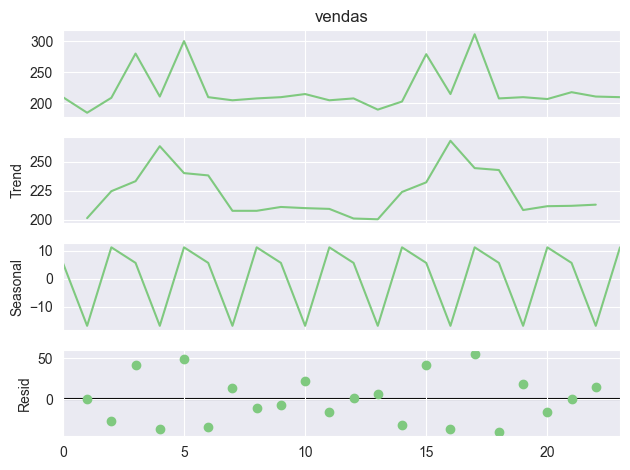

In [64]:
resultado = seasonal_decompose(chocolura['vendas'], period=3)
ax = resultado.plot()

In [65]:
observacao = resultado.observed
tendencia = resultado.trend
sazonalidade = resultado.seasonal
ruido = resultado.resid

In [68]:
data = ({
    'observacao': observacao, 
    'tendencia': tendencia, 
    'sazonalidade': sazonalidade, 
    'ruido': ruido
})

resultado = pd.DataFrame(data)
resultado.head()

,observacao,tendencia,sazonalidade,ruido
0,210.0,NaN,5.603175,NaN
1,185.0,201.333333,-16.730159,0.396825
2,209.0,224.666667,11.126984,-26.793651
3,280.0,233.333333,5.603175,41.063492
4,211.0,263.666667,-16.730159,-35.936508


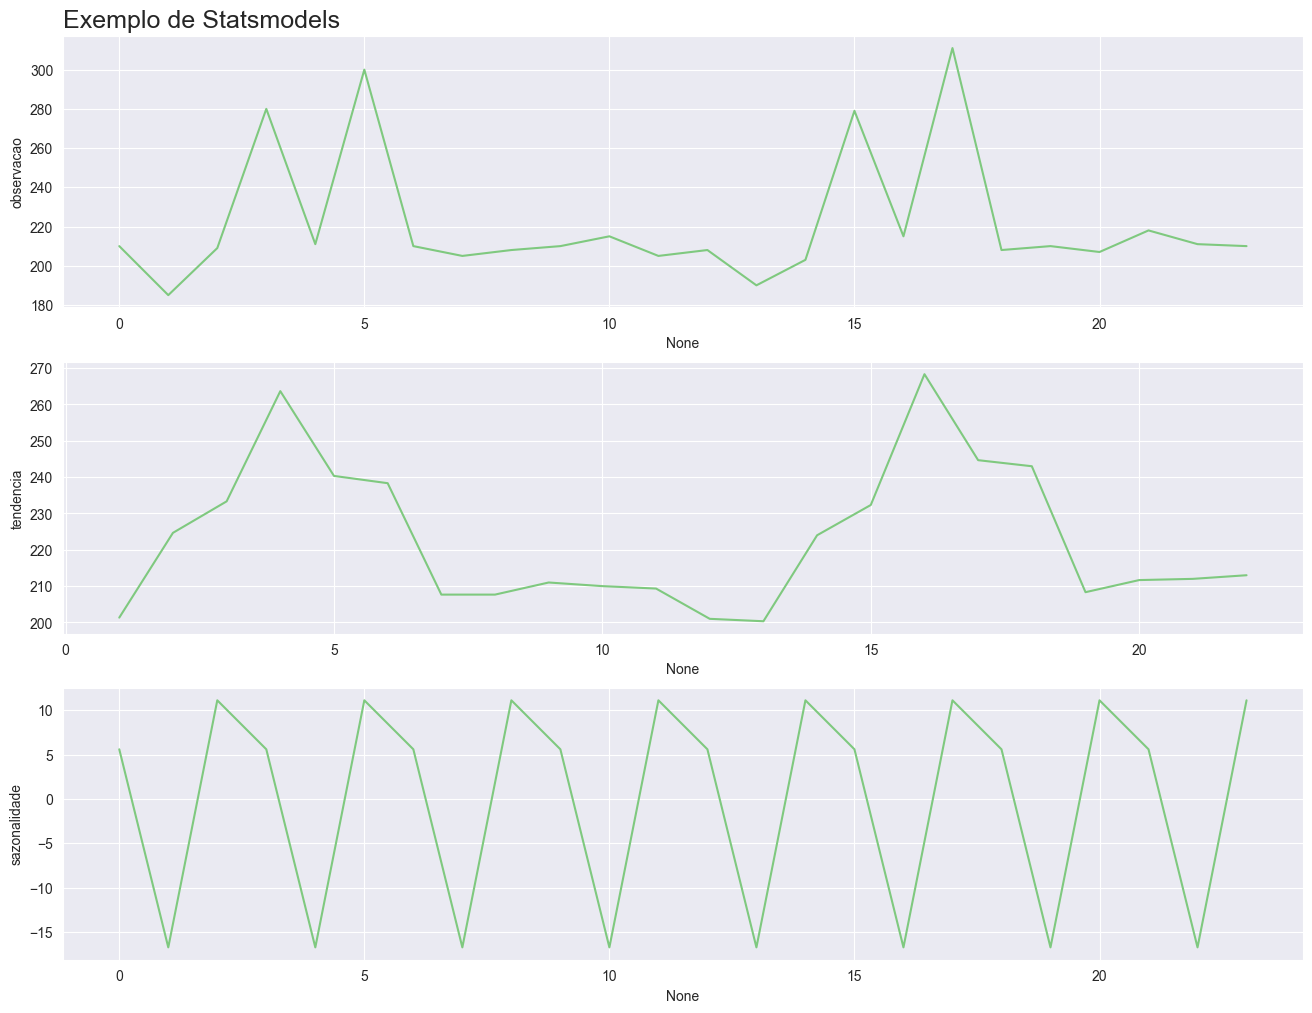

In [71]:
plot_comparacao(resultado.index, 'observacao', 'tendencia', 'sazonalidade', resultado, 'Exemplo de Statsmodels')

# Alucel - Análise de Vendas

In [72]:
uri_alucel = r'C:\Users\Usuario\Documents\Estudos\ALURA\05_Data_Science\raw\alucel.csv'
alucel = pd.read_csv(uri_alucel)
alucel.head()

,dia,vendas
0,2018-10-01,1374.83
1,2018-10-02,2185.69
2,2018-10-03,1860.36
3,2018-10-04,1939.02
4,2018-10-05,1946.17


In [73]:
alucel.dia = pd.to_datetime(alucel.dia)
alucel.dtypes

dia       datetime64[ns]
vendas           float64
dtype: object

In [74]:
print(alucel.shape)
print(alucel.isna().sum().sum())

(61, 2)
0


In [75]:
alucel['aumento'] = alucel.vendas.diff()
alucel['aceleracao'] = alucel.aumento.diff()
alucel.head()

,dia,vendas,aumento,aceleracao
0,2018-10-01,1374.83,NaN,NaN
1,2018-10-02,2185.69,810.86,NaN
2,2018-10-03,1860.36,-325.33,-1136.19
3,2018-10-04,1939.02,78.66,403.99
4,2018-10-05,1946.17,7.15,-71.51


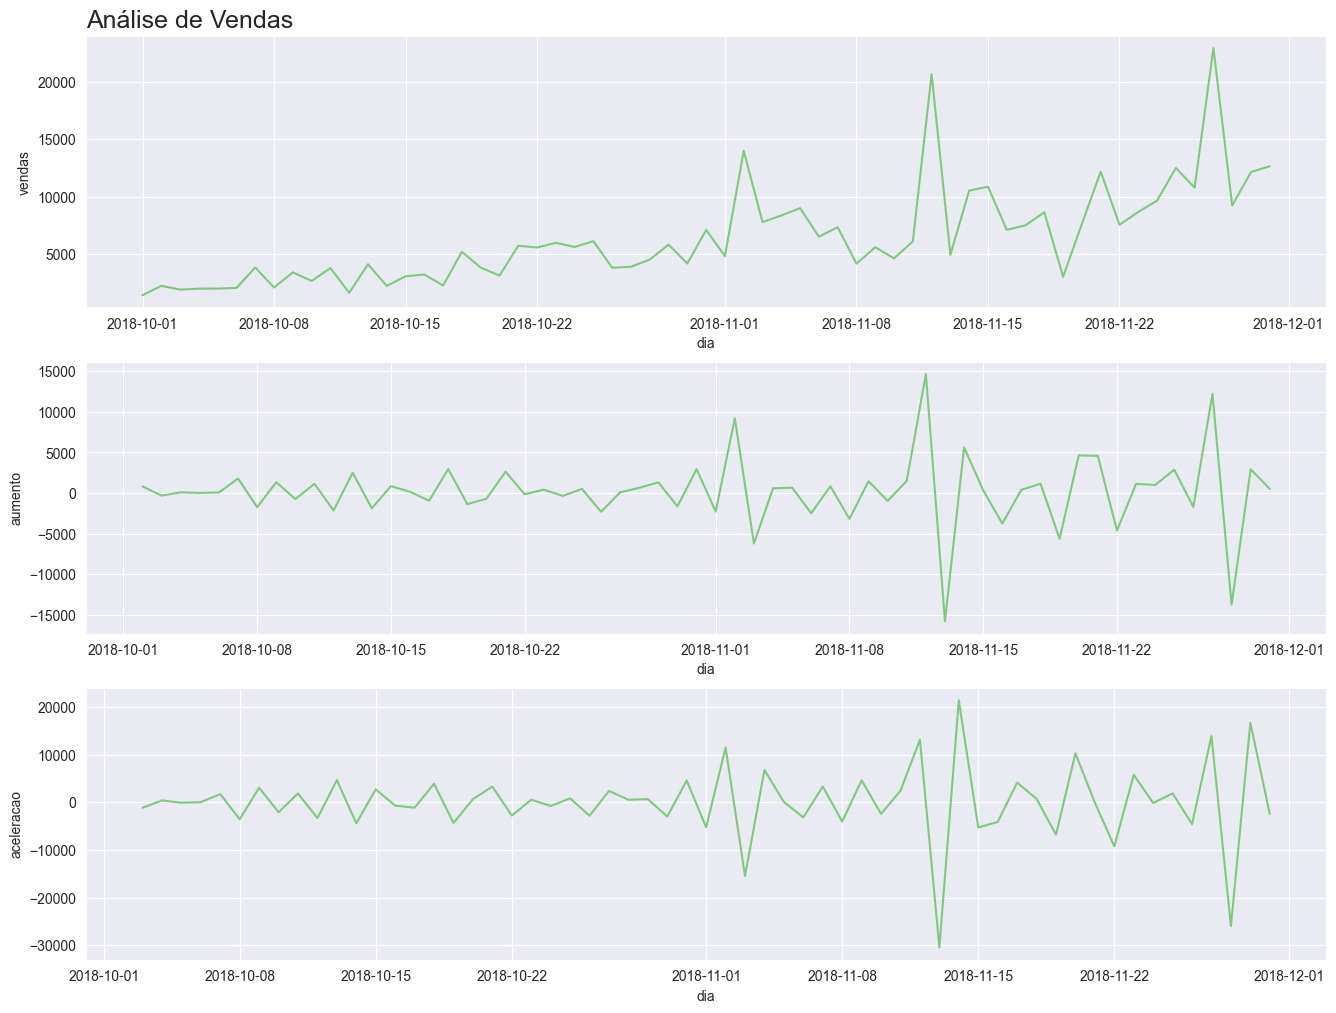

In [76]:
plot_comparacao('dia', 'vendas', 'aumento', 'aceleracao', alucel, 'Análise de Vendas')

## Média Móvel

In [77]:
alucel['media_movel'] = alucel['vendas'].rolling(7).mean()

In [79]:
alucel.head(7)

,dia,vendas,aumento,aceleracao,media_movel
0,2018-10-01,1374.83,NaN,NaN,NaN
1,2018-10-02,2185.69,810.86,NaN,NaN
2,2018-10-03,1860.36,-325.33,-1136.19,NaN
3,2018-10-04,1939.02,78.66,403.99,NaN
4,2018-10-05,1946.17,7.15,-71.51,NaN
5,2018-10-06,2005.89,59.72,52.57,NaN
6,2018-10-07,3793.07,1787.18,1727.46,2157.861429


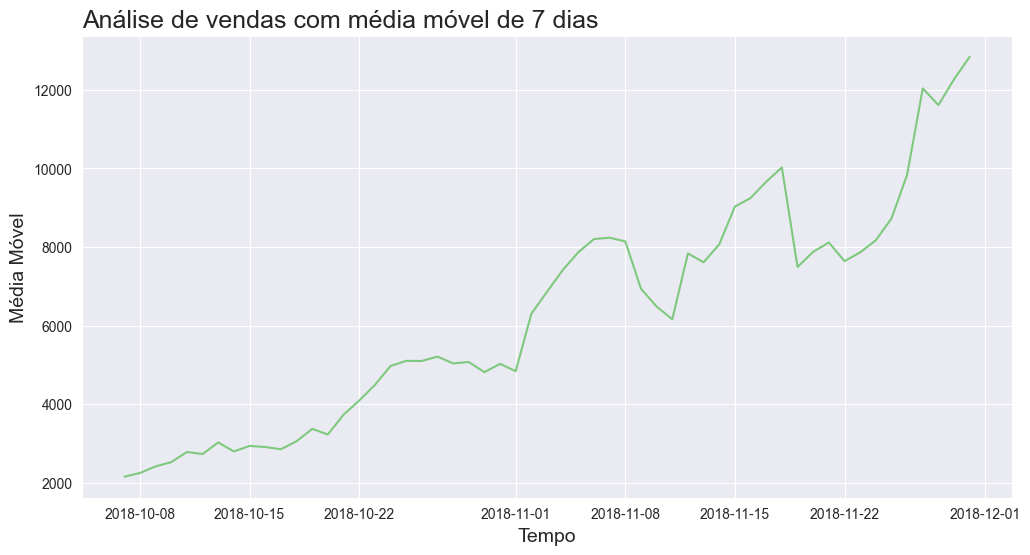

In [80]:
plotar('Análise de vendas com média móvel de 7 dias', 
       'Tempo', 'Média Móvel', 'dia', 'media_movel', alucel)

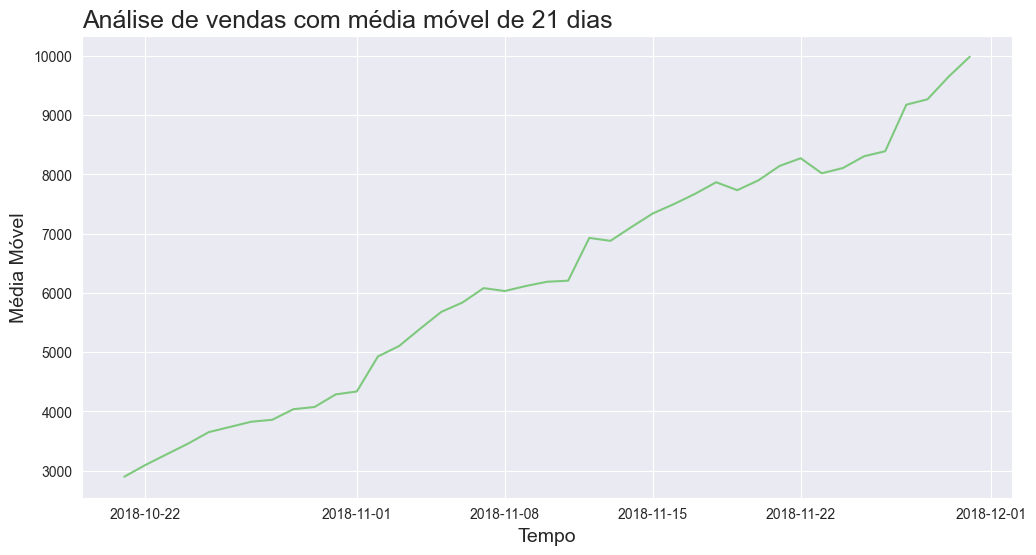

In [82]:
alucel['media_movel_21'] = alucel['vendas'].rolling(21).mean()
plotar('Análise de vendas com média móvel de 21 dias', 
       'Tempo', 'Média Móvel', 'dia', 'media_movel_21', alucel)

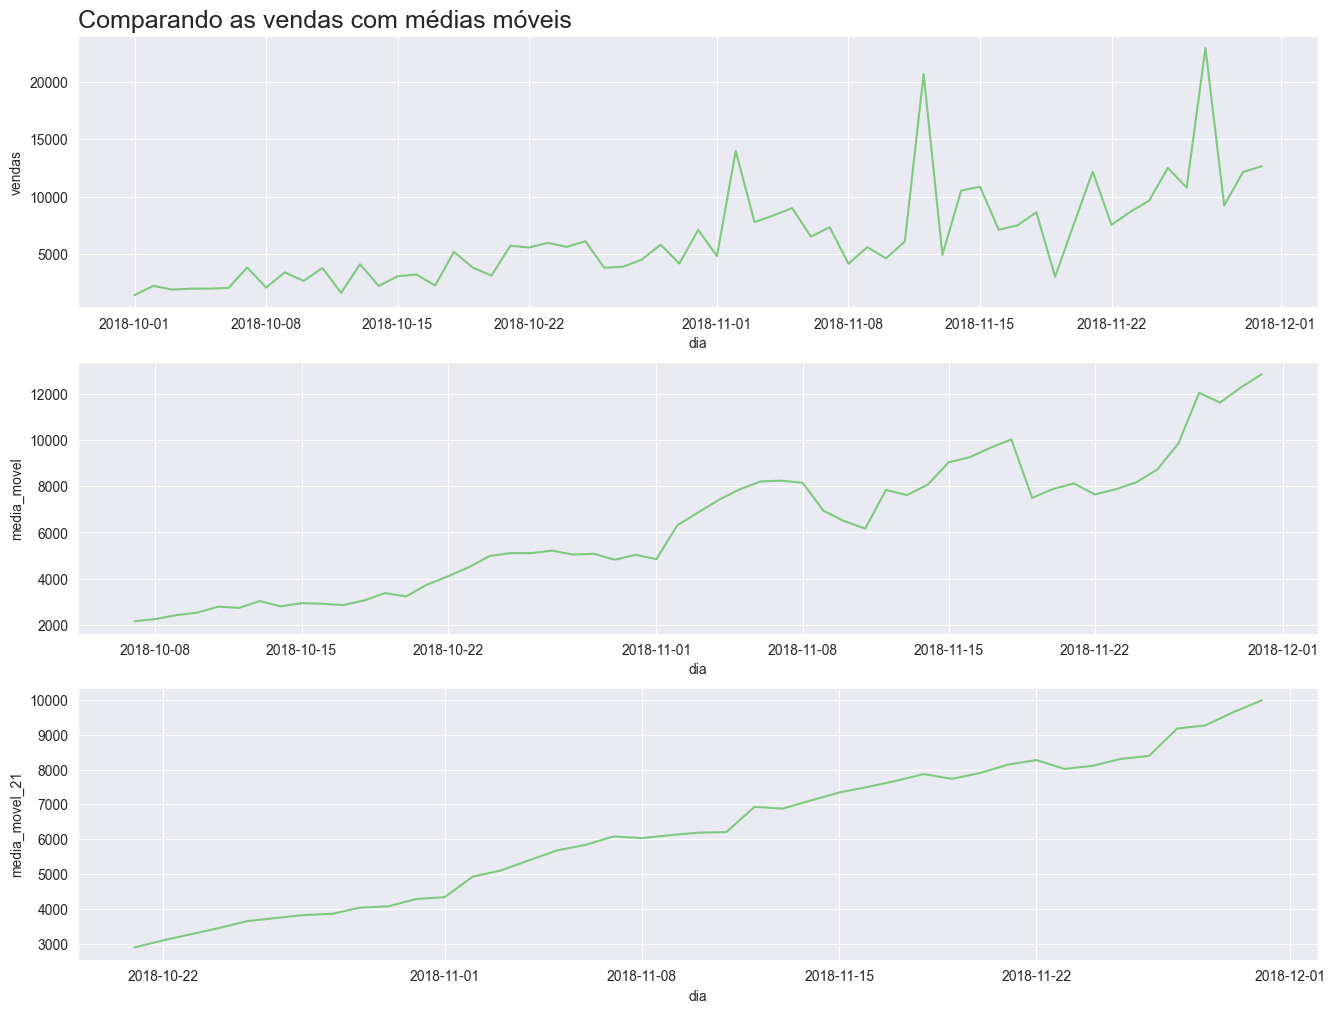

In [83]:
plot_comparacao('dia', 'vendas', 'media_movel', 'media_movel_21', alucel, 'Comparando as vendas com médias móveis')